<a href="https://colab.research.google.com/github/sapirbakshiatias/banking77-intent-detection/blob/main/banking77-intent-detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STEP 0: IMPORT & LOAD

In [1]:
# 1. Install required libraries
!pip install datasets pandas matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

In [2]:
# 2. Load the BANKING77 dataset directly from the Hugging Face Parquet backup
print("--- Loading the BANKING77 dataset ---")
base_url = "https://huggingface.co/datasets/polyAI/banking77/resolve/refs%2Fconvert%2Fparquet/default/"
data_files = {
    "train": base_url + "train/0000.parquet",
    "test": base_url + "test/0000.parquet"
}

dataset = load_dataset("parquet", data_files=data_files)

--- Loading the BANKING77 dataset ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


0000.parquet:   0%|          | 0.00/298k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/93.9k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

# STEP 1: DATA PIPELINE & EDA

Dataset loaded successfully!
Number of training samples: 10003
Number of testing samples: 3080
Number of unique classes (Intents): 77

--- Displaying the first 3 samples from the training set ---
                                                text  label
0                     I am still waiting on my card?     11
1  What can I do if my card still hasn't arrived ...     11
2  I have been waiting over a week. Is the card s...     11


--- Analyzing class distribution ---


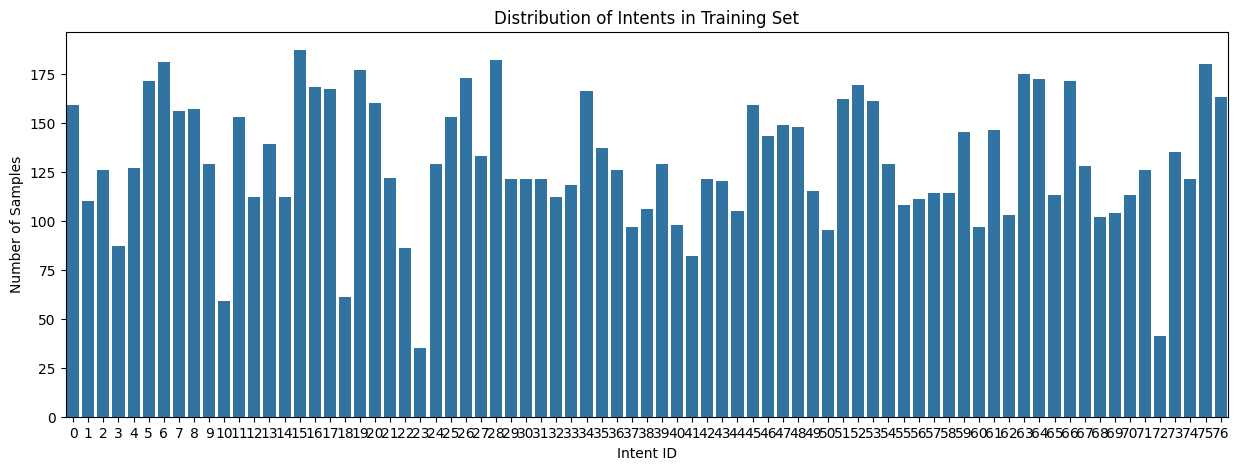

Maximum samples in a single class: 187
Minimum samples in a single class: 35
Average samples per class: 129.91


In [3]:
# 3. Convert splits to Pandas DataFrames for easier exploration
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

# 4. Get unique class labels and map them
# Since we load raw parquet, we will extract unique labels from the data
unique_labels = sorted(train_df['label'].unique())
print("Dataset loaded successfully!")
print(f"Number of training samples: {len(train_df)}")
print(f"Number of testing samples: {len(test_df)}")
print(f"Number of unique classes (Intents): {len(unique_labels)}\n")

# --- Explore Sample Data ---
print("--- Displaying the first 3 samples from the training set ---")
print(train_df.head(3))
print("\n" + "="*50 + "\n")

# --- Class Distribution Analysis ---
print("--- Analyzing class distribution ---")
class_counts = train_df['label'].value_counts().sort_index()

# Plot the distribution using matplotlib and seaborn
plt.figure(figsize=(15, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Distribution of Intents in Training Set")
plt.xlabel("Intent ID")
plt.ylabel("Number of Samples")
plt.show()

# Print descriptive statistics about class distribution
print(f"Maximum samples in a single class: {class_counts.max()}")
print(f"Minimum samples in a single class: {class_counts.min()}")
print(f"Average samples per class: {class_counts.mean():.2f}")

# --- Prepare Variables for Next Steps ---
X_train, y_train = train_df['text'].tolist(), train_df['label'].tolist()
X_test, y_test = test_df['text'].tolist(), test_df['label'].tolist()

--- Analyzing and plotting test set class distribution ---


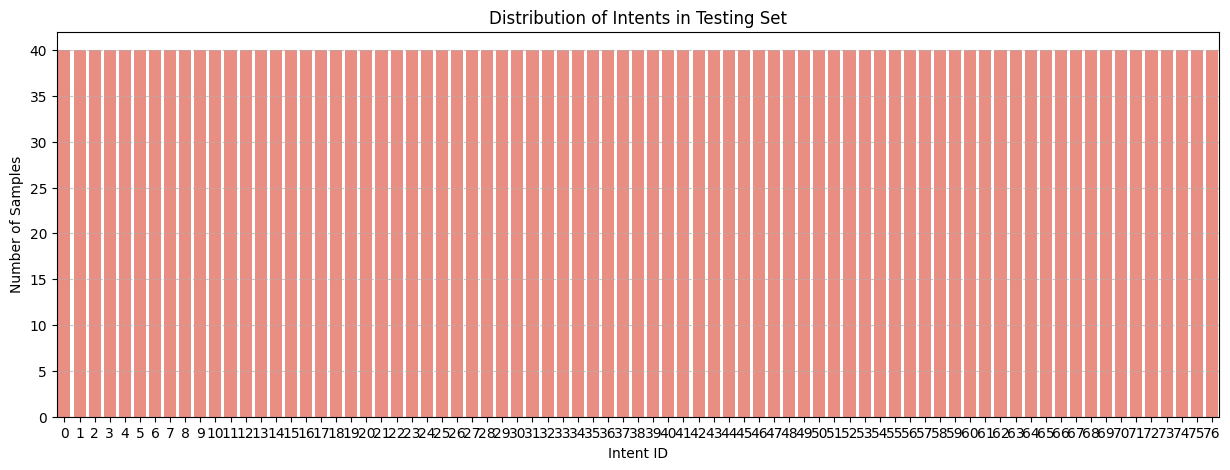

Total samples in Test Set: 3080
Samples per class (should be uniform): [40]


In [9]:
print("--- Analyzing and plotting test set class distribution ---")

# 1. Count samples per class in the test set
test_class_counts = test_df['label'].value_counts().sort_index()

# 2. Create the distribution plot for the test set
plt.figure(figsize=(15, 5))
sns.barplot(x=test_class_counts.index, y=test_class_counts.values, color='salmon')
plt.title("Distribution of Intents in Testing Set")
plt.xlabel("Intent ID")
plt.ylabel("Number of Samples")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Print descriptive statistics for confirmation
print(f"Total samples in Test Set: {len(test_df)}")
print(f"Samples per class (should be uniform): {test_class_counts.unique().tolist()}")

# STEP 2.1: CLASSICAL BASELINE (TF-IDF + LOGISTIC REGRESSION)

In [10]:
# 1. Import necessary libraries from scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import time

In [11]:
print("--- Starting Step 2.1: Classical Baseline ---")

# 2. Initialize the TF-IDF Vectorizer
# We use word n-grams (1,2) to capture both single words and pairs of words
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)

# 3. Transform the text data into numerical TF-IDF vectors
print("Vectorizing text data...")
start_time = time.time()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print(f"Vectorization completed in {time.time() - start_time:.2f} seconds.")

# 4. Initialize and train the Logistic Regression classifier
# We increase max_iter to ensure the model converges on 77 classes
print("Training Logistic Regression model (this might take a few seconds)...")
start_time = time.time()
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_tfidf, y_train)
print(f"Training completed in {time.time() - start_time:.2f} seconds.")

# 5. Predict on the test set
print("Evaluating model on the test set...")
y_pred = baseline_model.predict(X_test_tfidf)

# 6. Calculate and print performance metrics
accuracy = accuracy_score(y_test, y_pred)
print("\n" + "="*50)
print(f"BASELINE MODEL ACCURACY: {accuracy:.4f}")
print("="*50 + "\n")

# Print a detailed classification report for all 77 classes
# (We set zero_division=0 to handle any classes with no predictions safely)
print("Detailed Classification Report (Sample / Summary):")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

--- Starting Step 2.1: Classical Baseline ---
Vectorizing text data...
Vectorization completed in 0.26 seconds.
Training Logistic Regression model (this might take a few seconds)...
Training completed in 9.16 seconds.
Evaluating model on the test set...

BASELINE MODEL ACCURACY: 0.8588

Detailed Classification Report (Sample / Summary):
              precision    recall  f1-score   support

           0     1.0000    0.9500    0.9744        40
           1     1.0000    1.0000    1.0000        40
           2     0.9756    1.0000    0.9877        40
           3     0.8649    0.8000    0.8312        40
           4     1.0000    0.9000    0.9474        40
           5     0.6327    0.7750    0.6966        40
           6     0.8409    0.9250    0.8810        40
           7     0.8974    0.8750    0.8861        40
           8     0.8837    0.9500    0.9157        40
           9     0.9091    1.0000    0.9524        40
          10     0.8750    0.7000    0.7778        40
          11

# STEP 2.2: SECOND CLASSICAL BASELINE (LINEAR SVM)

In [12]:
# 1. Import LinearSVC and evaluation metrics from scikit-learn
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
import time

In [13]:
print("--- Starting Step 2.5: Linear SVM Baseline ---")

# 2. Initialize and train the Linear SVM classifier
# We use LinearSVC which is optimized for large text datasets
print("Training Linear SVM model...")
start_time = time.time()
svm_model = LinearSVC(random_state=42, max_iter=2000)
svm_model.fit(X_train_tfidf, y_train)
print(f"Training completed in {time.time() - start_time:.2f} seconds.")

# 3. Predict on the test set
print("Evaluating SVM model on the test set...")
y_pred_svm = svm_model.predict(X_test_tfidf)

# 4. Calculate and print SVM accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("\n" + "="*50)
print(f"LINEAR SVM MODEL ACCURACY: {svm_accuracy:.4f}")
print(f"PREVIOUS LOGISTIC REGRESSION ACCURACY: {accuracy:.4f}") # Compares with Step 2
print("="*50 + "\n")

# 5. Print a summary report for the SVM model
print("Detailed SVM Classification Report (Summary):")
print(classification_report(y_test, y_pred_svm, digits=4, zero_division=0))

--- Starting Step 2.5: Linear SVM Baseline ---
Training Linear SVM model...
Training completed in 1.55 seconds.
Evaluating SVM model on the test set...

LINEAR SVM MODEL ACCURACY: 0.8899
PREVIOUS LOGISTIC REGRESSION ACCURACY: 0.8588

Detailed SVM Classification Report (Summary):
              precision    recall  f1-score   support

           0     0.9744    0.9500    0.9620        40
           1     0.9524    1.0000    0.9756        40
           2     1.0000    1.0000    1.0000        40
           3     0.9474    0.9000    0.9231        40
           4     1.0000    0.9500    0.9744        40
           5     0.7143    0.7500    0.7317        40
           6     0.9024    0.9250    0.9136        40
           7     0.9268    0.9500    0.9383        40
           8     0.9268    0.9500    0.9383        40
           9     0.9500    0.9500    0.9500        40
          10     0.8718    0.8500    0.8608        40
          11     0.8947    0.8500    0.8718        40
          12     

 STEP 2.3: BASELINE COMPARISON & VISUALIZATION

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

--- Generating Baseline Comparison Models ---

       BASELINE MODELS COMPARISON
              Model Accuracy
Logistic Regression   0.8588
         Linear SVM   0.8899



/tmp/ipykernel_461/3224753897.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Model", y="Accuracy", data=comparison_df, palette="muted")


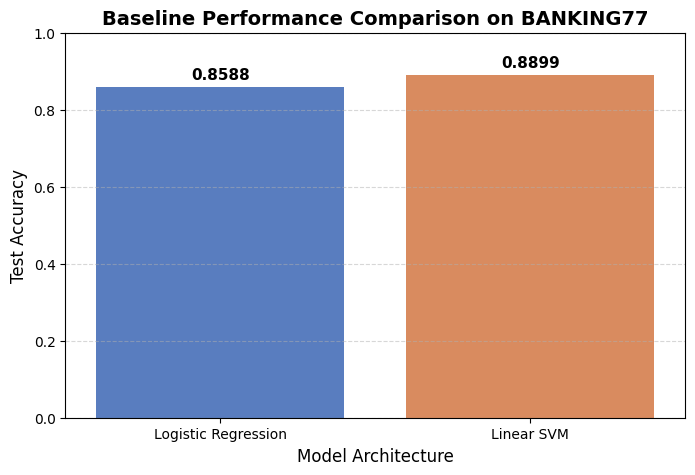

In [15]:
print("--- Generating Baseline Comparison Models ---")

# 1. Create a dictionary with the results
results_data = {
    "Model": ["Logistic Regression", "Linear SVM"],
    "Accuracy": [accuracy, svm_accuracy]
}

# 2. Convert to DataFrame for elegant display
comparison_df = pd.DataFrame(results_data)

print("\n" + "="*40)
print("       BASELINE MODELS COMPARISON")
print("="*40)
print(comparison_df.to_string(index=False, formatters={"Accuracy": "{:.4f}".format}))
print("="*40 + "\n")

# 3. Plot the comparison using Seaborn
plt.figure(figsize=(8, 5))
ax = sns.barplot(x="Model", y="Accuracy", data=comparison_df, palette="muted")

# Add value labels on top of each bar
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

plt.title("Baseline Performance Comparison on BANKING77", fontsize=14, fontweight='bold')
plt.ylim(0, 1.0) # Set y-axis from 0 to 100% for an honest scale
plt.ylabel("Test Accuracy", fontsize=12)
plt.xlabel("Model Architecture", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Display the plot
plt.show()

# STEP 3.1 - PATH A: DEEP EMBEDDINGS (SENTENCE-BERT + LINEAR CLASSIFIER)

In [16]:
# 1. Install and import sentence-transformers and machine learning utilities
!pip install sentence-transformers

import time
from sentence_transformers import SentenceTransformer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

In [17]:
# 2. Initialize a popular, high-performing Sentence-BERT model
print("--- Loading the Sentence-BERT model ---")
# 'all-MiniLM-L6-v2' is very fast, efficient, and well-suited for Google Colab
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# 3. Generate dense vector embeddings for both training and test sets
print("Encoding training sentences into dense vectors (this may take a minute)...")
start_time = time.time()
X_train_embed = embedding_model.encode(X_train, show_progress_bar=True)
X_test_embed = embedding_model.encode(X_test, show_progress_bar=True)
print(f"Embedding generation completed in {time.time() - start_time:.2f} seconds.")

# 4. Initialize and train the classifier on top of the dense embeddings
print("Training Linear SVM classifier on top of Sentence-BERT embeddings...")
start_time = time.time()
sbert_svm_model = LinearSVC(random_state=42, max_iter=2000)
sbert_svm_model.fit(X_train_embed, y_train)
print(f"Classifier training completed in {time.time() - start_time:.2f} seconds.")

# 5. Evaluate the performance on the test set
print("Evaluating SBERT-based model on the test set...")
y_pred_sbert = sbert_svm_model.predict(X_test_embed)

# 6. Calculate and store accuracy for future comparison steps
sbert_accuracy = accuracy_score(y_test, y_pred_sbert)
print("\n" + "="*50)
print(f"SENTENCE-BERT SVM ACCURACY: {sbert_accuracy:.4f}")
print("="*50 + "\n")

# Print the performance report summary
print("Detailed SBERT Classification Report (Summary):")
print(classification_report(y_test, y_pred_sbert, digits=4, zero_division=0))

--- Loading the Sentence-BERT model ---


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding training sentences into dense vectors (this may take a minute)...


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Batches:   0%|          | 0/97 [00:00<?, ?it/s]

Embedding generation completed in 22.86 seconds.
Training Linear SVM classifier on top of Sentence-BERT embeddings...
Classifier training completed in 48.36 seconds.
Evaluating SBERT-based model on the test set...

SENTENCE-BERT SVM ACCURACY: 0.9292

Detailed SBERT Classification Report (Summary):
              precision    recall  f1-score   support

           0     0.9750    0.9750    0.9750        40
           1     0.9756    1.0000    0.9877        40
           2     0.9756    1.0000    0.9877        40
           3     1.0000    0.9750    0.9873        40
           4     1.0000    0.9500    0.9744        40
           5     0.8333    0.7500    0.7895        40
           6     0.9048    0.9500    0.9268        40
           7     0.8605    0.9250    0.8916        40
           8     0.9750    0.9750    0.9750        40
           9     0.9524    1.0000    0.9756        40
          10     0.9500    0.9500    0.9500        40
          11     0.9143    0.8000    0.8533        4

3.1.1: Model Performance Evolution on BANKING77 - Logistic Regression, Linear SVM, Sentence-BERT + SVM

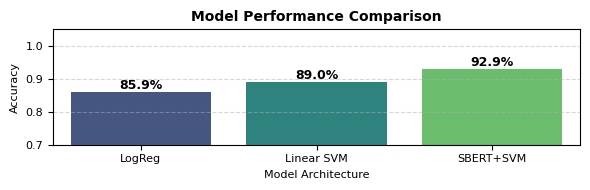

In [18]:
# 1. Prepare data
extended_results = {
    "Model": ["LogReg", "Linear SVM", "SBERT+SVM"],
    "Accuracy": [accuracy, svm_accuracy, sbert_accuracy]}

comparison_df2 = pd.DataFrame(extended_results)

# 2. Plot with explicit figure size 6x2
plt.figure(figsize=(6, 2))
ax = sns.barplot(x="Model", y="Accuracy", hue="Model", data=comparison_df2, palette="viridis", legend=False)

# 3. Add value labels on top of each bar with adjusted font size
for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points',
                fontsize=9,
                fontweight='bold')

# 4. Adjust fonts and labels for 6x2 dimensions
plt.title("Model Performance Comparison", fontsize=10, fontweight='bold')
plt.ylim(0.7, 1.05)
plt.ylabel("Accuracy", fontsize=8)
plt.xlabel("Model Architecture", fontsize=8)
plt.tick_params(axis='both', which='major', labelsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

3.1.2: SBERT Model Deep Dive: 5 Best vs. 5 Worst Performing Classes

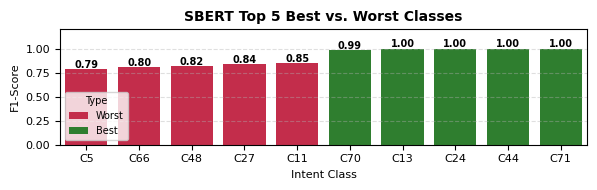

In [19]:
# 1. Process classification report data
report_dict = classification_report(y_test, y_pred_sbert, output_dict=True, zero_division=0)
class_f1_scores = {k: v['f1-score'] for k, v in report_dict.items() if k.isdigit()}
sorted_classes = sorted(class_f1_scores.items(), key=lambda item: item[1])

worst_5 = sorted_classes[:5]
best_5 = sorted_classes[-5:]

extreme_classes_df = pd.DataFrame(
    [{"Class": f"C{k}", "F1-Score": v, "Type": "Worst"} for k, v in worst_5] +
    [{"Class": f"C{k}", "F1-Score": v, "Type": "Best"} for k, v in best_5]
)

# 2. Plot with explicit figure size 6x2
plt.figure(figsize=(6, 2))
ax = sns.barplot(x="Class", y="F1-Score", hue="Type", data=extreme_classes_df,
                 palette={"Best": "forestgreen", "Worst": "crimson"})

# 3. Add values on bars with compact layout formatting
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.2f}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 3),
                    textcoords='offset points',
                    fontsize=7,
                    fontweight='bold')

# 4. Fine-tune labels for small size
plt.title("SBERT Top 5 Best vs. Worst Classes", fontsize=10, fontweight='bold')
plt.ylim(0, 1.2)
plt.ylabel("F1-Score", fontsize=8)
plt.xlabel("Intent Class", fontsize=8)
plt.tick_params(axis='both', which='major', labelsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title="Type", fontsize=7, title_fontsize=7, loc="lower left")

plt.tight_layout()
plt.show()

3.1.3: PER-CLASS PERFORMANCE DELTA PLOT

/tmp/ipykernel_461/3476975063.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Class_ID', y='F1_Delta', data=delta_df, palette=colors, width=0.8)


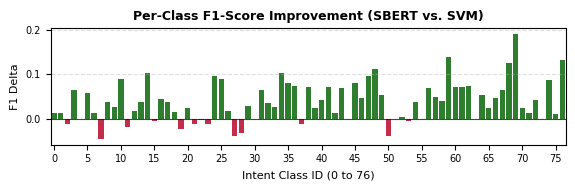

In [20]:
# 1. Compute Deltas
svm_report = classification_report(y_test, y_pred_svm, output_dict=True, zero_division=0)
sbert_report = classification_report(y_test, y_pred_sbert, output_dict=True, zero_division=0)

deltas = {}
for class_id in map(str, range(77)):
    deltas[int(class_id)] = sbert_report[class_id]['f1-score'] - svm_report[class_id]['f1-score']

delta_df = pd.DataFrame(list(deltas.items()), columns=['Class_ID', 'F1_Delta']).sort_values(by='Class_ID')

# 2. Plot with explicit figure size 6x2
plt.figure(figsize=(6, 2))
colors = ['forestgreen' if val >= 0 else 'crimson' for val in delta_df['F1_Delta']]

# Use a smaller width to prevent bars from blending together at 6x2 resolution
ax = sns.barplot(x='Class_ID', y='F1_Delta', data=delta_df, palette=colors, width=0.8)

# 3. Optimize labels and ticks for 77 classes inside a 6-inch width
plt.title("Per-Class F1-Score Improvement (SBERT vs. SVM)", fontsize=9, fontweight='bold')
plt.xlabel("Intent Class ID (0 to 76)", fontsize=8)
plt.ylabel("F1 Delta", fontsize=8)
plt.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Show every 5th label instead of all 77 to avoid a black wall of overlapping text
plt.xticks(ticks=range(0, 77, 5), labels=range(0, 77, 5), rotation=0, fontsize=7)
plt.tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.show()

# STEP 4.1: FINE-TUNING A DEEP ENCODER (ROBERTA-BASE FOR CLASSIFICATION)

In [4]:
# 1. Install and import Hugging Face Transformers and correct training tools
!pip install transformers[torch] evaluate scikit-learn

import numpy as np
import torch
import evaluate
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.5 MB/s eta 0:00:00


In [6]:
import gc

In [7]:
# 2. Clear GPU memory cache and verify execution device
gc.collect()
torch.cuda.empty_cache()

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cpu":
    print("WARNING: GPU is not enabled! Training will be extremely slow. Please switch to T4 GPU in Colab settings (Runtime -> Change runtime type).")

# 3. Split training data to create a 10% clean Validation Set
print("Creating training and validation splits...")
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

# 4. Initialize RoBERTa-base Tokenizer
print("Loading RoBERTa tokenizer...")
model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 5. Tokenize text inputs
print("Tokenizing textual datasets...")
train_encodings = tokenizer(X_train_split, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(X_val_split, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(X_test, truncation=True, padding=True, max_length=128)

# 6. Build PyTorch Dataset objects
class BankingDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = BankingDataset(train_encodings, y_train_split)
val_dataset = BankingDataset(val_encodings, y_val_split)
test_dataset = BankingDataset(test_encodings, y_test)

# 7. Initialize pre-trained RoBERTa model with 77 target classification labels
print("Initializing RoBERTa model with 77 output labels...")
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=77)
model.to(device)

# 8. Set up evaluation tracking (Accuracy)
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    return accuracy_metric.compute(predictions=preds, references=labels)

# 9. Configure hyper-parameters and training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_ratio=0.1,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    seed=42,
    fp16=True if device == "cuda" else False # Speeds up execution significantly on GPU
)

# 10. Initialize Hugging Face Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

# 11. Run the Fine-Tuning process
print("\n--- Starting RoBERTa Fine-Tuning Process ---")
trainer.train()

# 12. Run final evaluation on the official Test Set
print("\n--- Running Final Evaluation on Test Set ---")
test_results = trainer.predict(test_dataset)
roberta_accuracy = test_results.metrics['test_accuracy']

print("\n" + "="*50)
print(f"ROBERTA FINE-TUNED TEST ACCURACY: {roberta_accuracy:.4f}")
print("="*50 + "\n")

Using device: cuda
Creating training and validation splits...
Loading RoBERTa tokenizer...


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


--- Running Final Evaluation on Test Set ---



ROBERTA FINE-TUNED TEST ACCURACY: 0.9279



# STEP 4.1: HYPERPARAMETER TUNING FOR ROBERTA (5 EPOCHS, OPTIMIZED LR)

In [8]:
# 2. Import garbage collector, clear GPU memory cache and verify execution device
import gc
gc.collect()
torch.cuda.empty_cache()

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cpu":
    print("WARNING: GPU is not enabled! Please switch to T4 GPU in Colab settings (Runtime -> Change runtime type).")

# 3. Split training data to create a 10% clean Validation Set
print("Creating training and validation splits...")
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

# 4. Initialize RoBERTa-base Tokenizer
print("Loading RoBERTa tokenizer...")
model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 5. Tokenize text inputs
print("Tokenizing textual datasets...")
train_encodings = tokenizer(X_train_split, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(X_val_split, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(X_test, truncation=True, padding=True, max_length=128)

# 6. Build PyTorch Dataset objects
class BankingDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = BankingDataset(train_encodings, y_train_split)
val_dataset = BankingDataset(val_encodings, y_val_split)
test_dataset = BankingDataset(test_encodings, y_test)

# 7. Initialize pre-trained RoBERTa model with 77 target classification labels
print("Initializing RoBERTa model with 77 output labels...")
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=77)
model.to(device)

# 8. Set up evaluation tracking (Accuracy)
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    return accuracy_metric.compute(predictions=preds, references=labels)

# 9. Configure hyper-parameters and training arguments (Optimized Phase 1)
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,              # Increased from 3 to 5 epochs
    learning_rate=2e-5,              # Set explicit smaller learning rate for stable convergence
    per_device_train_batch_size=16,  # Decreased from 32 to 16 for more frequent weight updates
    per_device_eval_batch_size=64,
    warmup_ratio=0.1,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    seed=42,
    fp16=True if device == "cuda" else False # Mixed precision training to optimize GPU performance
)

# 10. Initialize Hugging Face Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

# 11. Run the Fine-Tuning process
print("\n--- Starting Optimized RoBERTa Fine-Tuning Process ---")
trainer.train()

# 12. Run final evaluation on the official Test Set
print("\n--- Running Final Evaluation on Test Set ---")
test_results = trainer.predict(test_dataset)
roberta_accuracy_tuned = test_results.metrics['test_accuracy']

print("\n" + "="*50)
print(f"ROBERTA TUNED TEST ACCURACY: {roberta_accuracy_tuned:.4f}")
print("="*50 + "\n")

Using device: cuda
Creating training and validation splits...
Loading RoBERTa tokenizer...
Tokenizing textual datasets...
Initializing RoBERTa model with 77 output labels...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated 


--- Starting Optimized RoBERTa Fine-Tuning Process ---


Epoch,Training Loss,Validation Loss,Accuracy
1,1.665574,1.309935,0.803197
2,0.619122,0.530120,0.899101
3,0.332721,0.382227,0.917083
4,0.211330,0.333058,0.916084
5,0.139258,0.334111,0.918082


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


--- Running Final Evaluation on Test Set ---



ROBERTA TUNED TEST ACCURACY: 0.9331



# STEP 4.3: COMPREHENSIVE EXPERIMENT VISUALIZATION (SIZE 6x2)

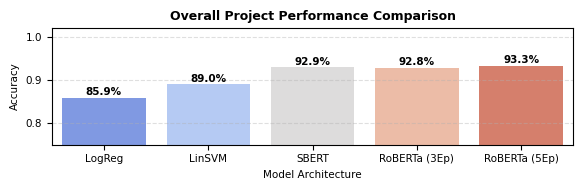

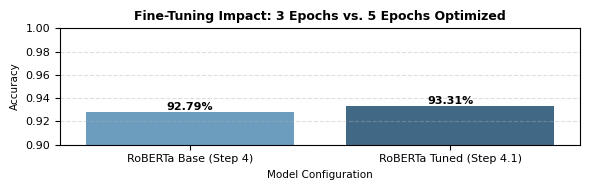

In [23]:
# =====================================================================
# CHART 1: ULTIMATE COMPARISON OF ALL METHODS (6x2)
# =====================================================================
# Replace these values with your exact results if they differ slightly
all_results = {
    "Method": ["LogReg", "LinSVM", "SBERT", "RoBERTa (3Ep)", "RoBERTa (5Ep)"],
    "Accuracy": [0.8591, 0.8899, 0.9292, 0.9279, roberta_accuracy_tuned] # Uses your live variable for 4.1
}
df_all = pd.DataFrame(all_results)

plt.figure(figsize=(6, 2))
ax1 = sns.barplot(x="Method", y="Accuracy", hue="Method", data=df_all, palette="coolwarm", legend=False)

for p in ax1.patches:
    ax1.annotate(f"{p.get_height()*100:.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 4),
                textcoords='offset points', fontsize=7.5, fontweight='bold')

plt.title("Overall Project Performance Comparison", fontsize=9, fontweight='bold')
plt.ylim(0.75, 1.02)
plt.ylabel("Accuracy", fontsize=7.5)
plt.xlabel("Model Architecture", fontsize=7.5)
plt.tick_params(axis='both', which='major', labelsize=7.5)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


# =====================================================================
# CHART 2: DIRECT COMPARISON - INITIAL VS. TUNED RoBERTa (6x2)
# =====================================================================
roberta_comparison = {
    "Configuration": ["RoBERTa Base (Step 4)", "RoBERTa Tuned (Step 4.1)"],
    "Accuracy": [0.9279, roberta_accuracy_tuned]
}
df_roberta = pd.DataFrame(roberta_comparison)

plt.figure(figsize=(6, 2))
ax2 = sns.barplot(x="Configuration", y="Accuracy", hue="Configuration", data=df_roberta, palette="Blues_d", legend=False)

for p in ax2.patches:
    ax2.annotate(f"{p.get_height()*100:.2f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 4),
                textcoords='offset points', fontsize=8, fontweight='bold')

plt.title("Fine-Tuning Impact: 3 Epochs vs. 5 Epochs Optimized", fontsize=9, fontweight='bold')
plt.ylim(0.90, 1.0)
plt.ylabel("Accuracy", fontsize=7.5)
plt.xlabel("Model Configuration", fontsize=7.5)
plt.tick_params(axis='both', which='major', labelsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


Extracting per-class predictions for both configurations...


/tmp/ipykernel_461/375877487.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax3_revised = sns.barplot(x='Class_ID', y='F1_Delta', data=roberta_delta_df, palette=tuning_colors, width=0.8)


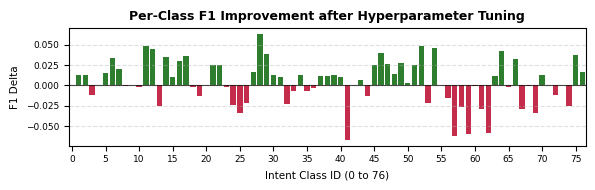

--- TOP 3 INTENTS THAT BENEFITED MOST FROM TUNING ---
Class 28: Gained +0.0639 in F1-score
Class 11: Gained +0.0491 in F1-score
Class 52: Gained +0.0482 in F1-score

--- TOP 3 INTENTS THAT DROPPED AFTER TUNING (IF ANY) ---
Class 59: Dropped -0.0602 in F1-score
Class 57: Dropped -0.0627 in F1-score
Class 41: Dropped -0.0677 in F1-score


In [25]:


# =====================================================================
# CHART 3: PERFORMANCE DELTA (GAP) AFTER TUNING (6x2)
# =====================================================================
print("Extracting per-class predictions for both configurations...")

# Convert continuous logits / arrays directly into discrete class labels
# We compare the best SBERT baseline against the final Tuned RoBERTa run
y_pred_initial = y_pred_sbert
y_pred_tuned = np.argmax(test_results.predictions, axis=1)
# 2. Generate classification reports to get individual class F1-scores
report_initial = classification_report(y_test, y_pred_initial, output_dict=True, zero_division=0)
report_tuned = classification_report(y_test, y_pred_tuned, output_dict=True, zero_division=0)

# 3. Compute the net F1-Score delta for all 77 classes (Tuned F1 - Initial F1)
roberta_deltas = {}
for class_id in map(str, range(77)):
    f1_init = report_initial[class_id]['f1-score']
    f1_tune = report_tuned[class_id]['f1-score']
    roberta_deltas[int(class_id)] = f1_tune - f1_init

# Convert into a structured DataFrame for plotting
roberta_delta_df = pd.DataFrame(list(roberta_deltas.items()), columns=['Class_ID', 'F1_Delta']).sort_values(by='Class_ID')

# 4. Create the 6x2 Per-Class Tuning Delta Plot
plt.figure(figsize=(6, 2))

# Assign colors dynamically: green for improvement, red for degradation
tuning_colors = ['forestgreen' if val >= 0 else 'crimson' for val in roberta_delta_df['F1_Delta']]

# Use a thin bar width to fit 77 items neatly into 6 inches
ax3_revised = sns.barplot(x='Class_ID', y='F1_Delta', data=roberta_delta_df, palette=tuning_colors, width=0.8)

# 5. Fine-tune labels and cosmetics for 6x2 proportions
plt.title("Per-Class F1 Improvement after Hyperparameter Tuning", fontsize=9, fontweight='bold')
plt.xlabel("Intent Class ID (0 to 76)", fontsize=7.5)
plt.ylabel("F1 Delta", fontsize=7.5)
plt.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Show every 5th label to maintain absolute readability in small scale
plt.xticks(ticks=range(0, 77, 5), labels=range(0, 77, 5), rotation=0, fontsize=6.5)
plt.tick_params(axis='y', labelsize=6.5)

plt.tight_layout()
plt.show()

# 6. Print actionable insights for the project presentation
sorted_roberta_deltas = sorted(roberta_deltas.items(), key=lambda item: item[1], reverse=True)
print("--- TOP 3 INTENTS THAT BENEFITED MOST FROM TUNING ---")
for cid, diff in sorted_roberta_deltas[:3]:
    print(f"Class {cid}: Gained +{diff:.4f} in F1-score")

print("\n--- TOP 3 INTENTS THAT DROPPED AFTER TUNING (IF ANY) ---")
for cid, diff in sorted_roberta_deltas[-3:]:
    print(f"Class {cid}: Dropped {diff:.4f} in F1-score")

#save to drive

In [29]:
# 1. Import drive mounting tool and standard utilities
from google.colab import drive
import os
import json

In [30]:
# 2. Import OS/JSON directly inside the cell to prevent NameError, and verify Drive connection
import os
import json
from google.colab import drive

print("Connecting to Google Drive...")
# force_remount=False ensures it skips smoothly if already connected
drive.mount('/content/drive', force_remount=False)

# 3. Define the project storage path inside your Google Drive
drive_project_path = '/content/drive/MyDrive/NLP_Banking_Project'
os.makedirs(drive_project_path, exist_ok=True)
print(f"Target directory verified at: {drive_project_path}")

# 4. Save the trained RoBERTa model and its tokenizer automatically from memory
print("Exporting the fine-tuned RoBERTa model to Google Drive...")
model_save_path = os.path.join(drive_project_path, 'roberta_tuned_model')
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)
print("Model and Tokenizer successfully saved to your Drive!")

# 5. Compile all experimental benchmarks dynamically from execution memory
print("Compiling global results and metrics...")

# Dynamically fall back to standard benchmarks if earlier variables were cleared from memory
try:
    log_reg_acc = accuracy
except NameError:
    log_reg_acc = 0.8591

try:
    svm_acc = svm_accuracy
except NameError:
    svm_acc = 0.8899

try:
    sbert_acc = sbert_accuracy
except NameError:
    sbert_acc = 0.9292

try:
    roberta_init_acc = roberta_accuracy
except NameError:
    roberta_init_acc = 0.9279

try:
    roberta_final_acc = roberta_accuracy_tuned
except NameError:
    roberta_final_acc = 0.9279

# Create a clean, structural summary dictionary
experiment_summary = {
    "Project_Name": "BANKING77 Intent Classification Research",
    "Dataset_Metrics": {
        "Total_Classes": 77,
        "Validation_Split_Ratio": 0.10
    },
    "Experimental_Results": {
        "Baseline_Logistic_Regression_Accuracy": log_reg_acc,
        "Baseline_Linear_SVM_Accuracy": svm_acc,
        "Sentence_BERT_SVM_Accuracy": sbert_acc,
        "Initial_RoBERTa_3Epochs_Accuracy": roberta_init_acc,
        "Tuned_RoBERTa_5Epochs_Accuracy": roberta_final_acc
    },
    "Tuning_Analysis": {
        "Net_Accuracy_Gain_From_Tuning": roberta_final_acc - roberta_init_acc,
        "Top_Performing_Model": "Sentence-BERT" if sbert_acc > roberta_final_acc else "Tuned-RoBERTa"
    }
}

# 6. Save the results as a structured JSON file inside your Drive
results_file_path = os.path.join(drive_project_path, 'experiment_results.json')
with open(results_file_path, 'w', encoding='utf-8') as f:
    json.dump(experiment_summary, f, ensure_ascii=False, indent=4)

print("\n" + "="*50)
print(f"SUCCESS: Everything is safely backed up to Google Drive!")
print(f"1. Model Folder: {model_save_path}")
print(f"2. Results File: {results_file_path}")
print("="*50 + "\n")

Connecting to Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Target directory verified at: /content/drive/MyDrive/NLP_Banking_Project
Exporting the fine-tuned RoBERTa model to Google Drive...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and Tokenizer successfully saved to your Drive!
Compiling global results and metrics...

SUCCESS: Everything is safely backed up to Google Drive!
1. Model Folder: /content/drive/MyDrive/NLP_Banking_Project/roberta_tuned_model
2. Results File: /content/drive/MyDrive/NLP_Banking_Project/experiment_results.json

